# Inference Visualization and Analysis

In [1]:
import sys
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, HTML

sys.path.append('..')
from tools.config import Config
from core.environment import Environment
from core.inference import ModelInference
from core.model import GraphPolicy

c:\Users\victo\miniconda3\envs\Deep\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## State Visualization Functions

In [2]:
from core.state import StateHandler

def plot_state(env, state, title="State Visualization", ax=None, show_routes=True, show_boundary=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 14))
    
    assigned_job_ids = set()
    for route in state.routes:
        assigned_job_ids.update(StateHandler.get_job_ids_in_route(route))
    
    if show_routes and state.routes:
        colors = plt.cm.tab10(np.linspace(0, 1, min(10, len(state.routes))))
        
        for idx, route in enumerate(state.routes):
            vehicle_id = route['vehicle']
            vehicle = next(v for v in env.vehicles if v['id'] == vehicle_id)
            color = colors[idx % 10]
            
            path_coords = route.get('path_coords', [])
            
            if path_coords:
                lons = [coord[1] for coord in path_coords]
                lats = [coord[0] for coord in path_coords]
                ax.plot(lons, lats, c=color, alpha=0.8, linewidth=3.5, zorder=2,
                       label=f'Route {idx+1} (Veh {vehicle_id})')
            else:
                job_ids = StateHandler.get_job_ids_in_route(route)
                
                if job_ids:
                    route_jobs = [j for j in env.jobs if j['id'] in job_ids]
                    
                    route_lons = [vehicle['start'][0]]
                    route_lats = [vehicle['start'][1]]
                    
                    for job in route_jobs:
                        route_lons.append(job['location'][0])
                        route_lats.append(job['location'][1])
                    
                    ax.plot(route_lons, route_lats, c=color, alpha=0.8, linewidth=3.5, 
                           marker='o', markersize=4, linestyle='-', zorder=2,
                           label=f'Route {idx+1} (Veh {vehicle_id})')
    
    unassigned_jobs = [j for j in env.jobs if j['id'] not in assigned_job_ids]
    if unassigned_jobs:
        unassigned_lons = [j['location'][0] for j in unassigned_jobs]
        unassigned_lats = [j['location'][1] for j in unassigned_jobs]
        ax.scatter(unassigned_lons, unassigned_lats, c='red', marker='x', s=200, 
                  label='Unassigned Jobs', zorder=4, linewidths=3)
        for job in unassigned_jobs:
            ax.text(job['location'][0], job['location'][1], f" J{job['id']}", 
                   fontsize=8, fontweight='bold', color='darkred', 
                   ha='left', va='bottom', zorder=6)
    
    assigned_jobs = [j for j in env.jobs if j['id'] in assigned_job_ids]
    if assigned_jobs:
        assigned_lons = [j['location'][0] for j in assigned_jobs]
        assigned_lats = [j['location'][1] for j in assigned_jobs]
        ax.scatter(assigned_lons, assigned_lats, c='green', marker='o', s=150, 
                  label='Assigned Jobs', zorder=4, alpha=0.8, edgecolors='darkgreen', linewidths=1.5)
        for job in assigned_jobs:
            ax.text(job['location'][0], job['location'][1], f" J{job['id']}", 
                   fontsize=8, fontweight='bold', color='darkgreen', 
                   ha='left', va='bottom', zorder=6)
    
    vehicle_lons = [v['start'][0] for v in env.vehicles]
    vehicle_lats = [v['start'][1] for v in env.vehicles]
    ax.scatter(vehicle_lons, vehicle_lats, c='blue', marker='^', s=300, 
              label='Vehicles', zorder=5, edgecolors='black', linewidths=2)
    for vehicle in env.vehicles:
        ax.text(vehicle['start'][0], vehicle['start'][1], f" V{vehicle['id']}", 
               fontsize=9, fontweight='bold', color='darkblue', 
               ha='left', va='top', zorder=6)
    
    center_lon, center_lat = env.config.env.center
    radius_km = env.config.env.radius
    
    lat_rad = np.radians(center_lat)
    km_per_deg_lat = 110.574
    km_per_deg_lon = 111.320 * np.abs(np.cos(lat_rad))
    
    radius_with_padding = radius_km * 1.5
    delta_lon = radius_with_padding / km_per_deg_lon
    delta_lat = radius_with_padding / km_per_deg_lat
    
    ax.set_xlim(center_lon - delta_lon, center_lon + delta_lon)
    ax.set_ylim(center_lat - delta_lat, center_lat + delta_lat)
    
    if show_boundary:
        circle_radius_lon = radius_km / km_per_deg_lon
        circle_radius_lat = radius_km / km_per_deg_lat
        circle = plt.Circle((center_lon, center_lat), radius=circle_radius_lon, 
                           fill=False, color='gray', linestyle='--', linewidth=2, 
                           alpha=0.5, label='Generation Area', zorder=1)
        ax.add_patch(circle)
        
        ax.plot(center_lon, center_lat, 'k+', markersize=15, markeredgewidth=2, 
               label='Center', zorder=3)
    
    ax.set_aspect('equal', adjustable='box')
    
    ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
    ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc='best', fontsize=9, framealpha=0.95, ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    stats_text = f"Routes: {state.num_routes}\nAssigned: {len(assigned_job_ids)}\nUnassigned: {state.num_unassigned}\nCost: {state.cost}"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9),
            fontsize=10, fontweight='bold')


def plot_state_comparison(env, old_state, new_state, title="Before vs After"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(28, 13))
    
    plot_state(env, old_state, "BEFORE", ax=ax1)
    plot_state(env, new_state, "AFTER", ax=ax2)
    
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## Load Model and Run Inference

In [6]:
config = Config()
env = Environment(config)
env.reset()
initial_state = env.current_state.copy()

model = GraphPolicy(config)
# model.load_state_dict(torch.load("./runs/run_20260212-223806/graph_ppo_policy.pt", map_location=torch.device('cpu')))

inference = ModelInference(model, env, max_steps=5, device="cuda")
result = inference.run(initial_state)

print(f"Inference completed: {result.total_steps} steps")
print(f"Stopped reason: {result.stopped_reason}")

Inference completed: 5 steps
Stopped reason: max_steps_reached


## Initial State Parameters

In [7]:
initial = result.initial_state
print("="*60)
print("INITIAL STATE")
print("="*60)
print(f"Total Cost: {initial.cost}")
print(f"Number of Routes: {initial.num_routes}")
print(f"Number of Unassigned: {initial.num_unassigned}")
print(f"\nRoute Details:")
for i, route in enumerate(initial.routes):
    print(f"  Route {i}: {len(route)} jobs - {route}")
print(f"\nUnassigned Jobs: {initial.unassigned}")

INITIAL STATE
Total Cost: 7645
Number of Routes: 3
Number of Unassigned: 9

Route Details:
  Route 0: 16 jobs - {'vehicle': 0, 'cost': 338, 'description': 'Vehicle 0', 'delivery': [1], 'amount': [1], 'pickup': [0], 'setup': 0, 'service': 300, 'duration': 338, 'waiting_time': 0, 'priority': 3, 'distance': 2995, 'steps': [{'type': 'start', 'location': [-46.75, -23.583106], 'setup': 0, 'service': 0, 'waiting_time': 0, 'load': [1], 'arrival': 28800, 'duration': 0, 'violations': [], 'distance': 0}, {'type': 'job', 'description': 'Job 3', 'location': [-46.744295, -23.56833], 'id': 3, 'setup': 0, 'service': 300, 'waiting_time': 0, 'job': 3, 'load': [0], 'arrival': 29138, 'duration': 338, 'violations': [], 'distance': 2995}, {'type': 'end', 'location': [-46.744295, -23.56833], 'setup': 0, 'service': 0, 'waiting_time': 0, 'load': [0], 'arrival': 29438, 'duration': 338, 'violations': [], 'distance': 2995}], 'violations': [], 'geometry': 'ja}nClxi|GI@E?M@??Q?UBCAK?MAICGAYIQEMEKESAM?E@I@SH{C`BKBQ@

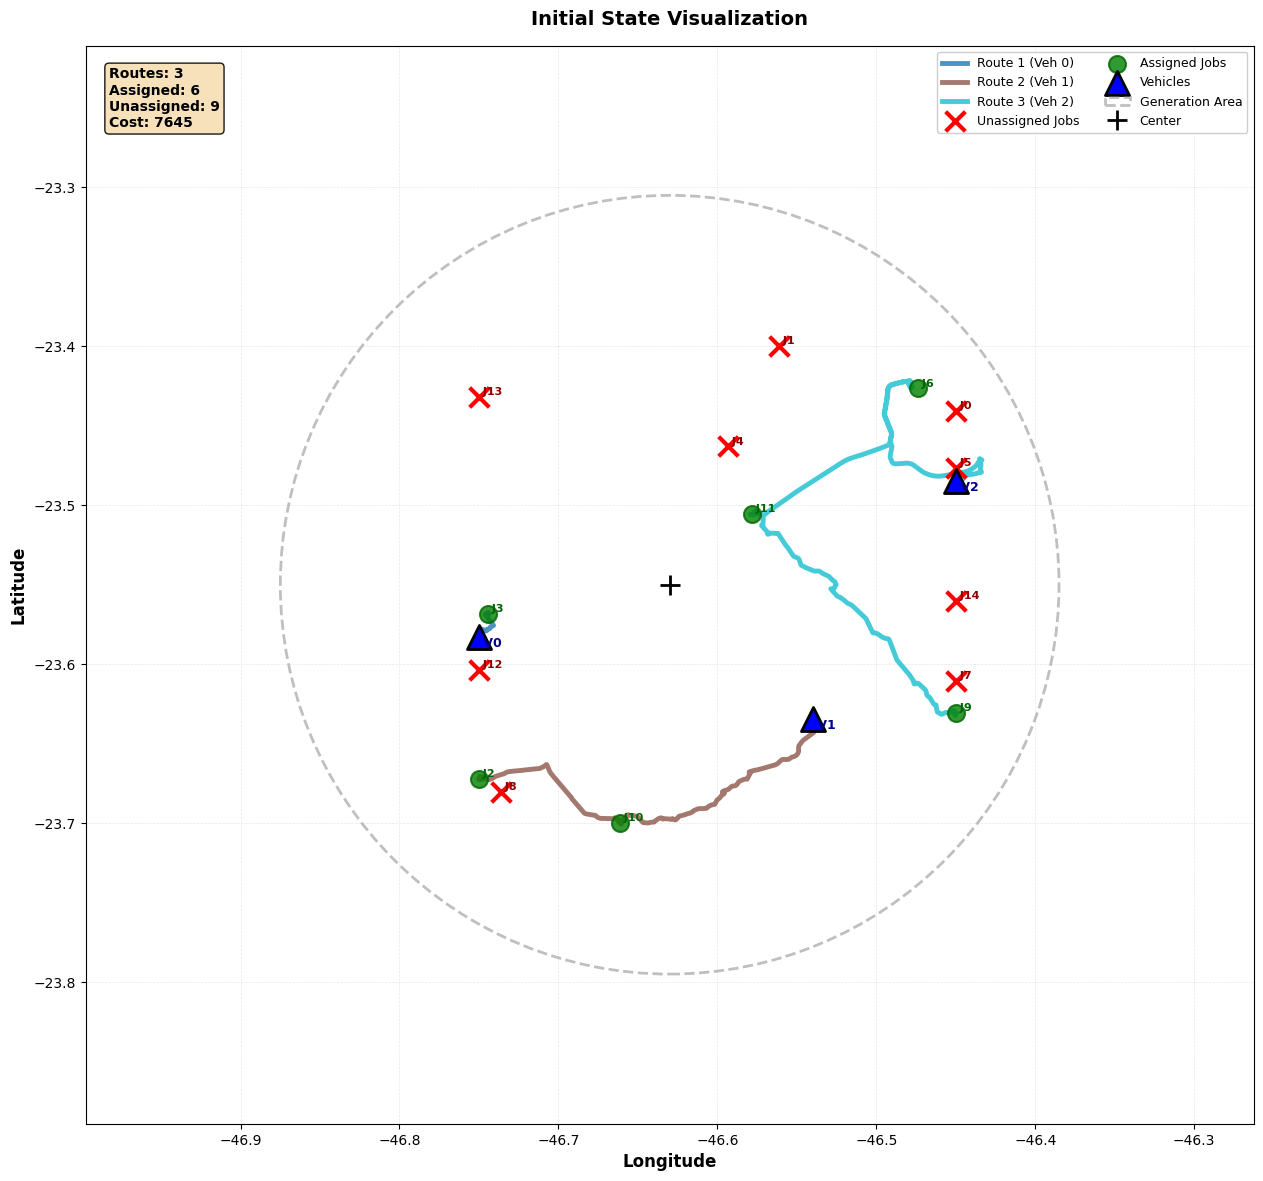

In [8]:
plot_state(env, initial, title="Initial State Visualization")

## Step-by-Step Analysis

In [9]:
for idx in range(1, len(result.steps)):
    step = result.steps[idx]
    prev_step = result.steps[idx-1]
    
    print("\n" + "="*60)
    print(f"STEP {step.step_number}")
    print("="*60)
    
    if step.action_info:
        print(f"\nAction: {step.action_info['operator_name']}")
        print(f"Vehicle ID: {step.action_info['vehicle_id']}")
        print(f"Job ID: {step.action_info['job_id']}")
    
    print(f"\nBEFORE:")
    print(f"  Cost: {prev_step.cost}")
    print(f"  Routes: {prev_step.num_routes}")
    print(f"  Unassigned: {prev_step.num_unassigned}")
    
    print(f"\nAFTER:")
    print(f"  Cost: {step.cost}")
    print(f"  Routes: {step.num_routes}")
    print(f"  Unassigned: {step.num_unassigned}")
    
    cost_delta = step.cost - prev_step.cost
    print(f"\nCost Change: {cost_delta:+d}")
    
    if step.reward_info:
        print(f"\nReward Info:")
        for key, value in step.reward_info.items():
            print(f"  {key}: {value}")


STEP 1

Action: REOPTIMIZE
Vehicle ID: 0
Job ID: 3

BEFORE:
  Cost: 7645
  Routes: 3
  Unassigned: 9

AFTER:
  Cost: 7645
  Routes: 3
  Unassigned: 9

Cost Change: +0

Reward Info:
  distance_reward: -0.0
  unassigned_reward: -0.0
  idle_reward: -0.0
  priority_reward: -0.0
  action_reward: -1.5
  old_distance_cost: 11.4675
  old_unassigned_cost: 9.0
  old_idle_cost: 0.0
  old_priority_cost: 9.0
  new_distance_cost: 11.4675
  new_unassigned_cost: 9.0
  new_idle_cost: 0.0
  new_priority_cost: 9.0

STEP 2

Action: REMOVE
Vehicle ID: 1
Job ID: 2

BEFORE:
  Cost: 7645
  Routes: 3
  Unassigned: 9

AFTER:
  Cost: 6467
  Routes: 3
  Unassigned: 10

Cost Change: -1178

Reward Info:
  distance_reward: 1.7669999999999995
  unassigned_reward: -1.0
  idle_reward: -0.0
  priority_reward: -2.0
  action_reward: 1.5
  old_distance_cost: 11.4675
  old_unassigned_cost: 9.0
  old_idle_cost: 0.0
  old_priority_cost: 9.0
  new_distance_cost: 9.7005
  new_unassigned_cost: 10.0
  new_idle_cost: 0.0
  new_pr

## Visual Comparison: Before and After Each Step

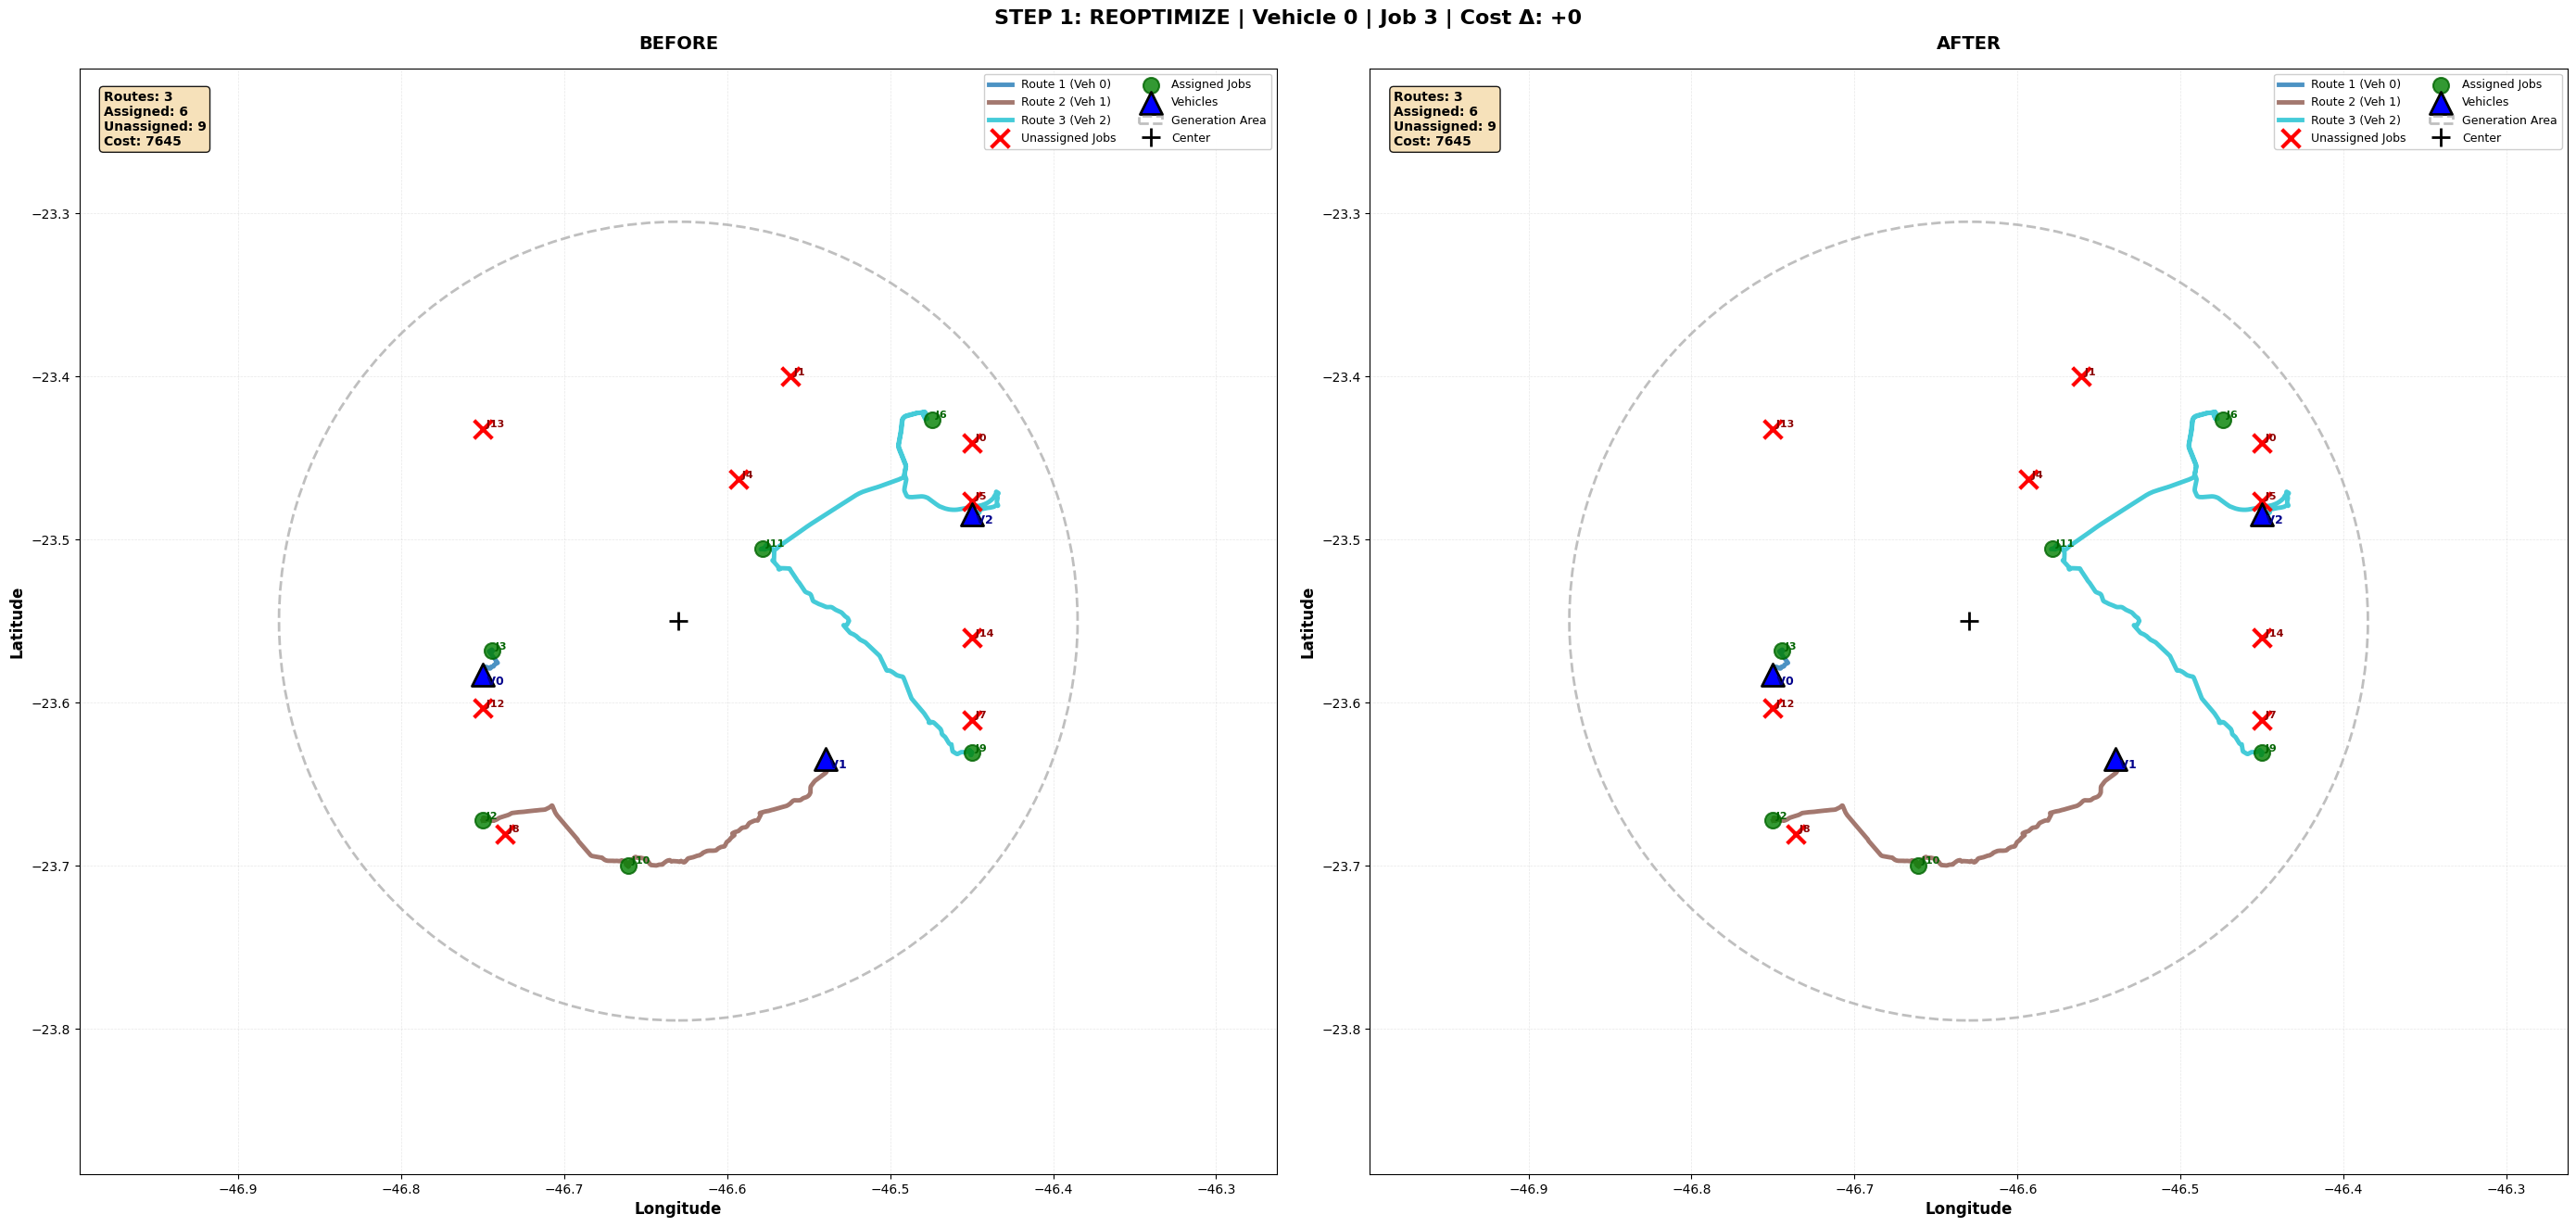

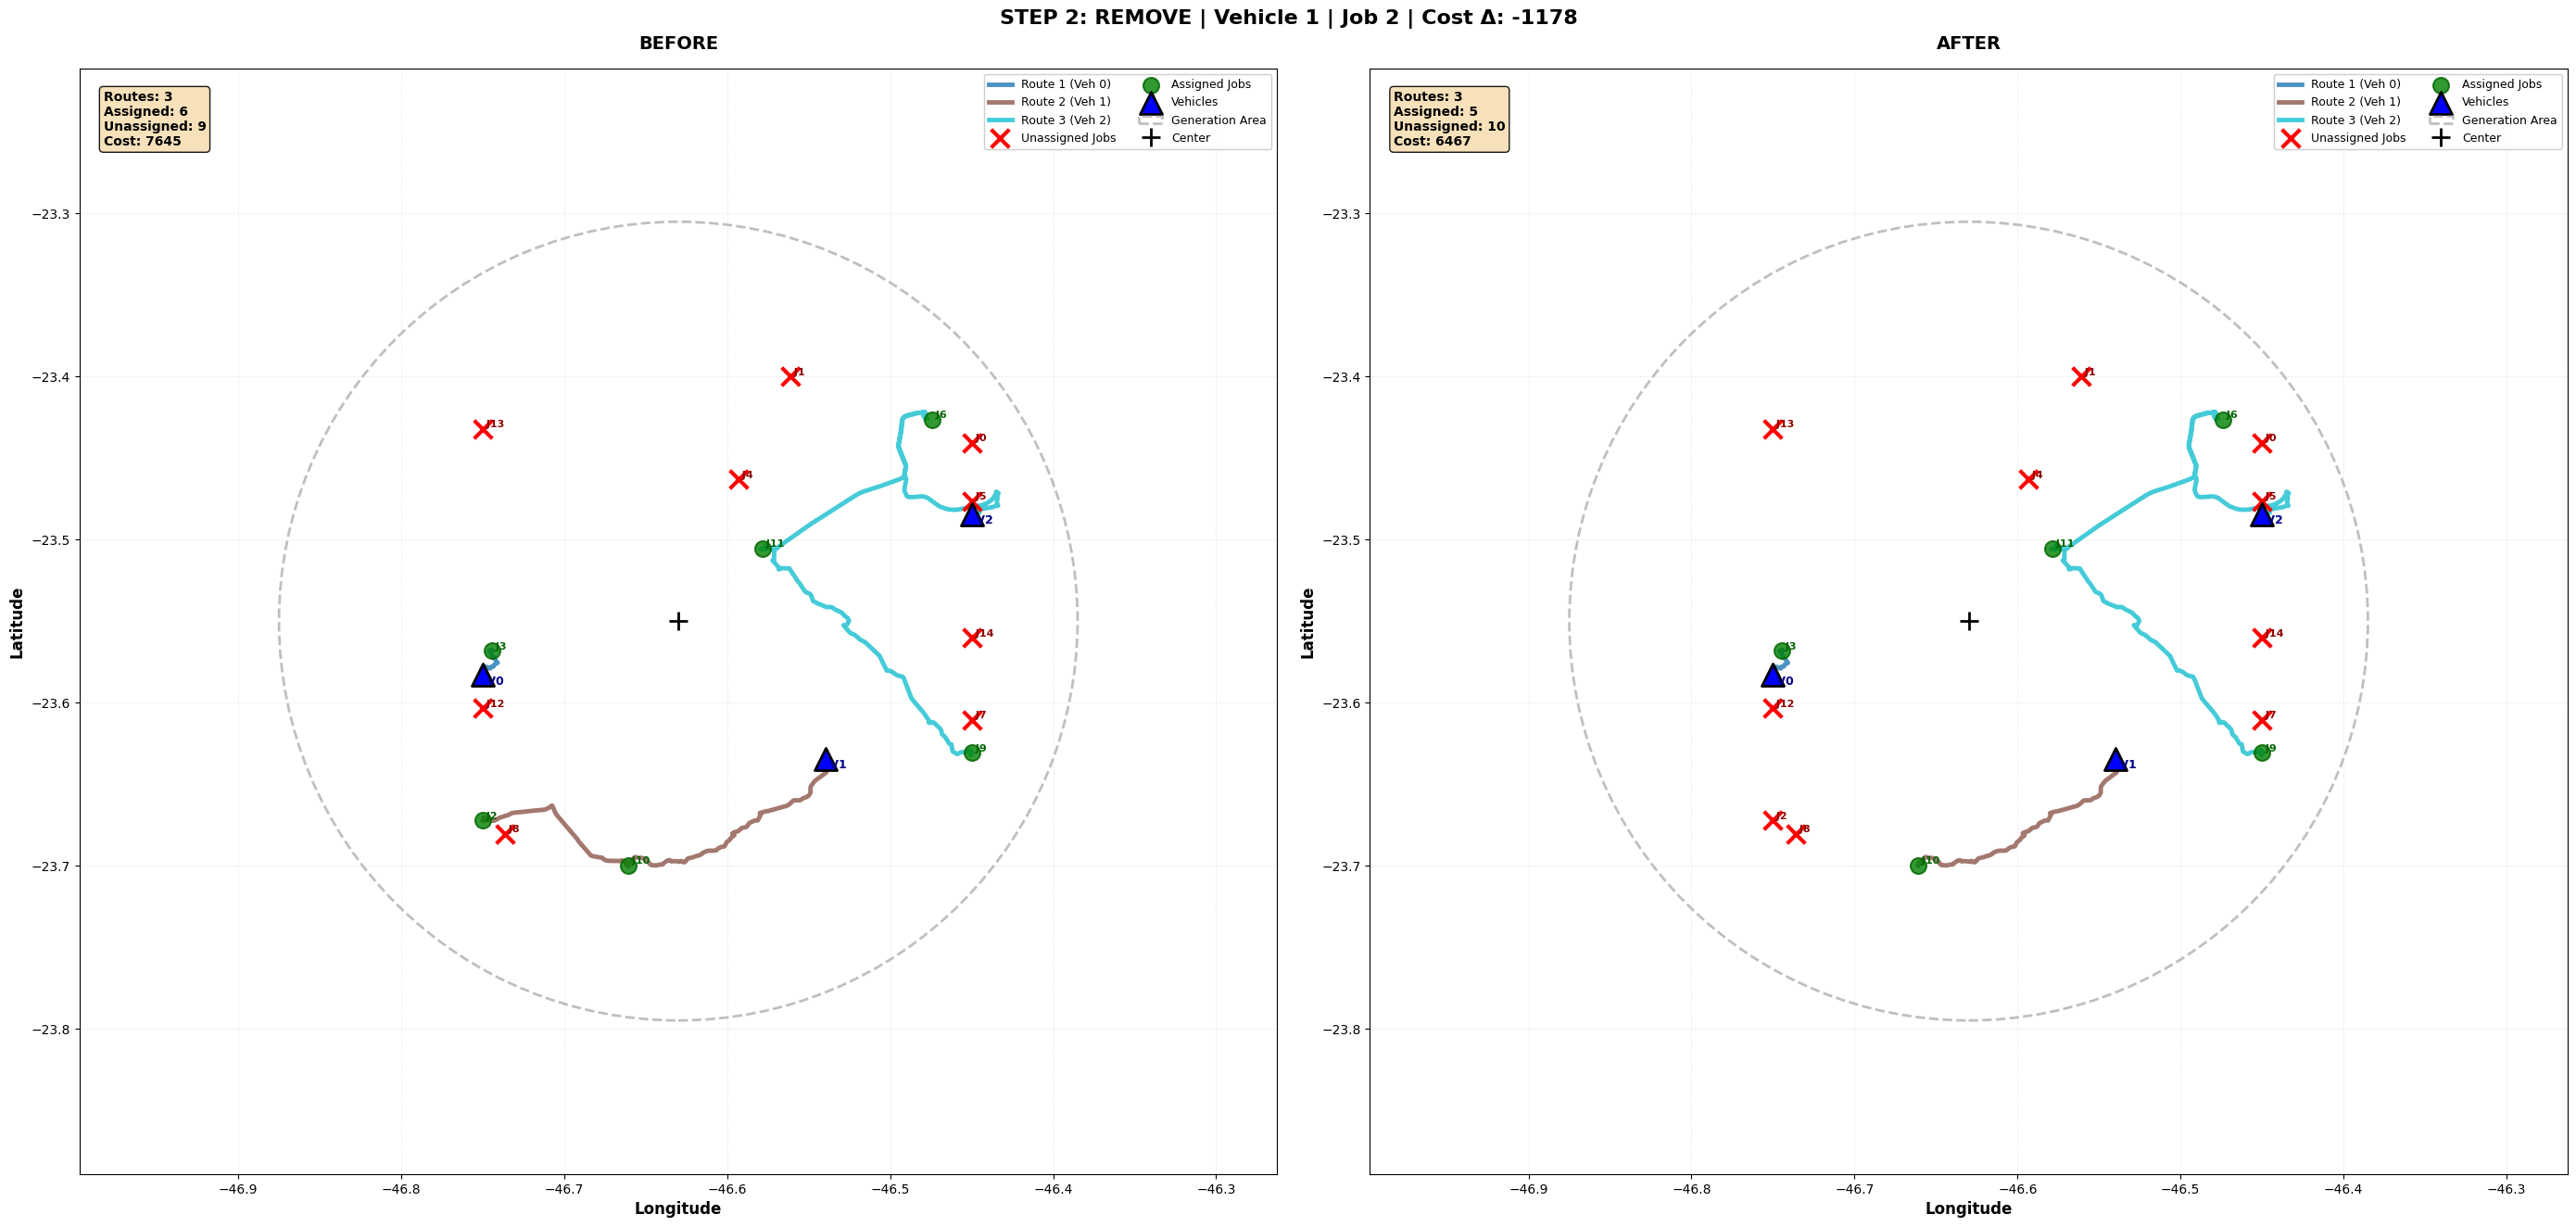

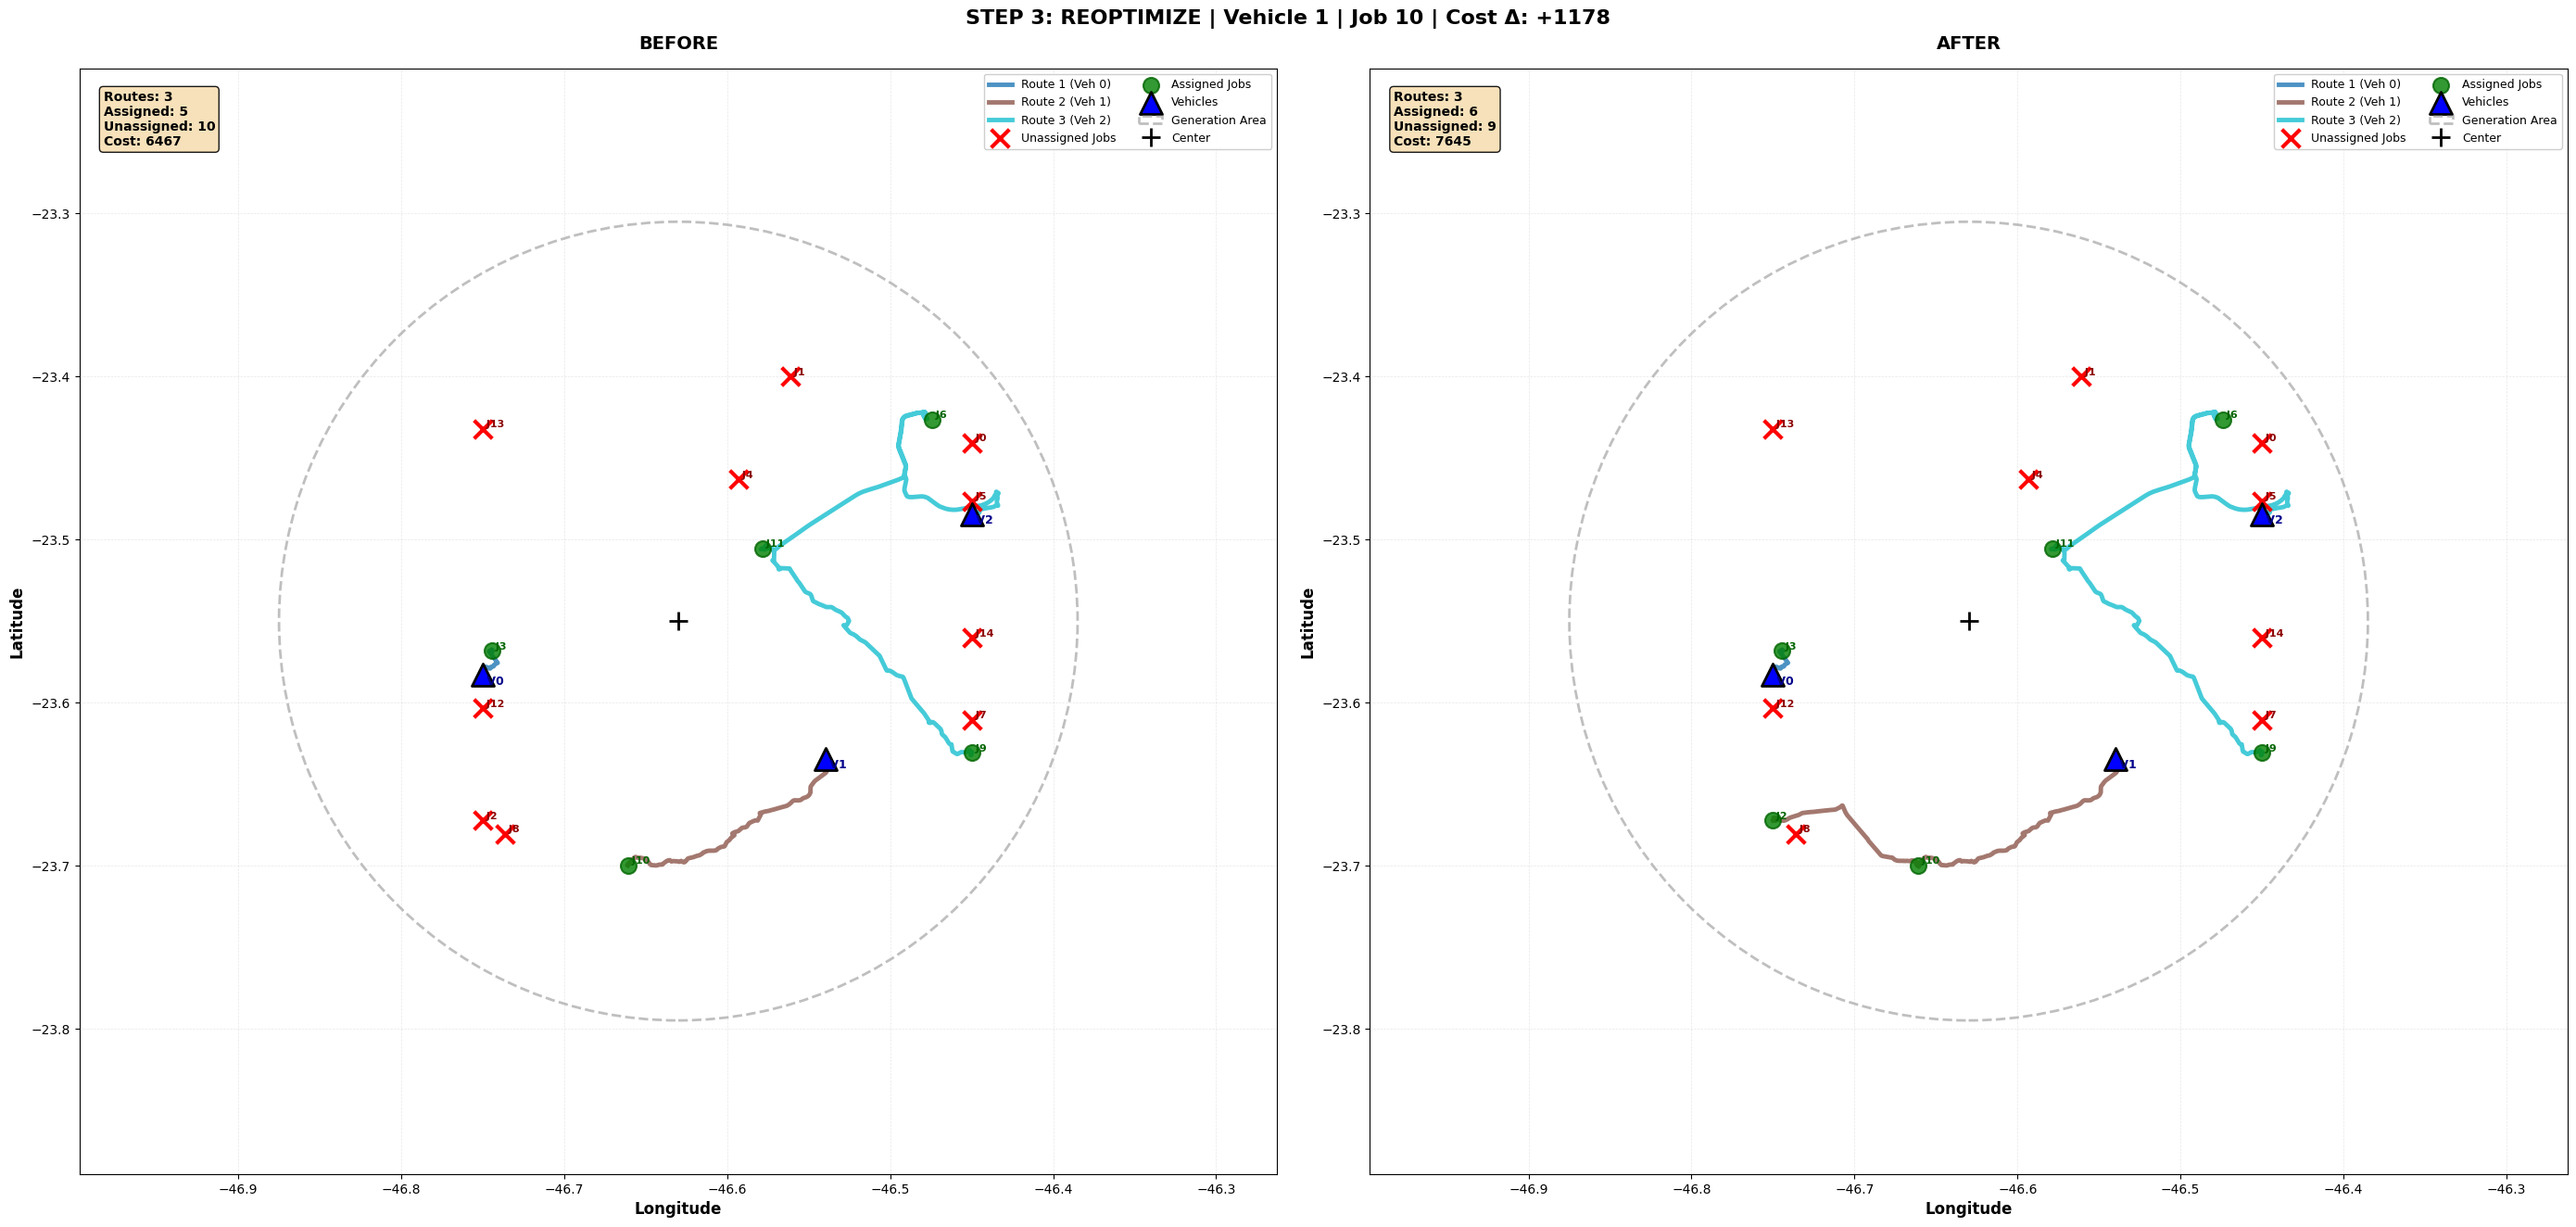

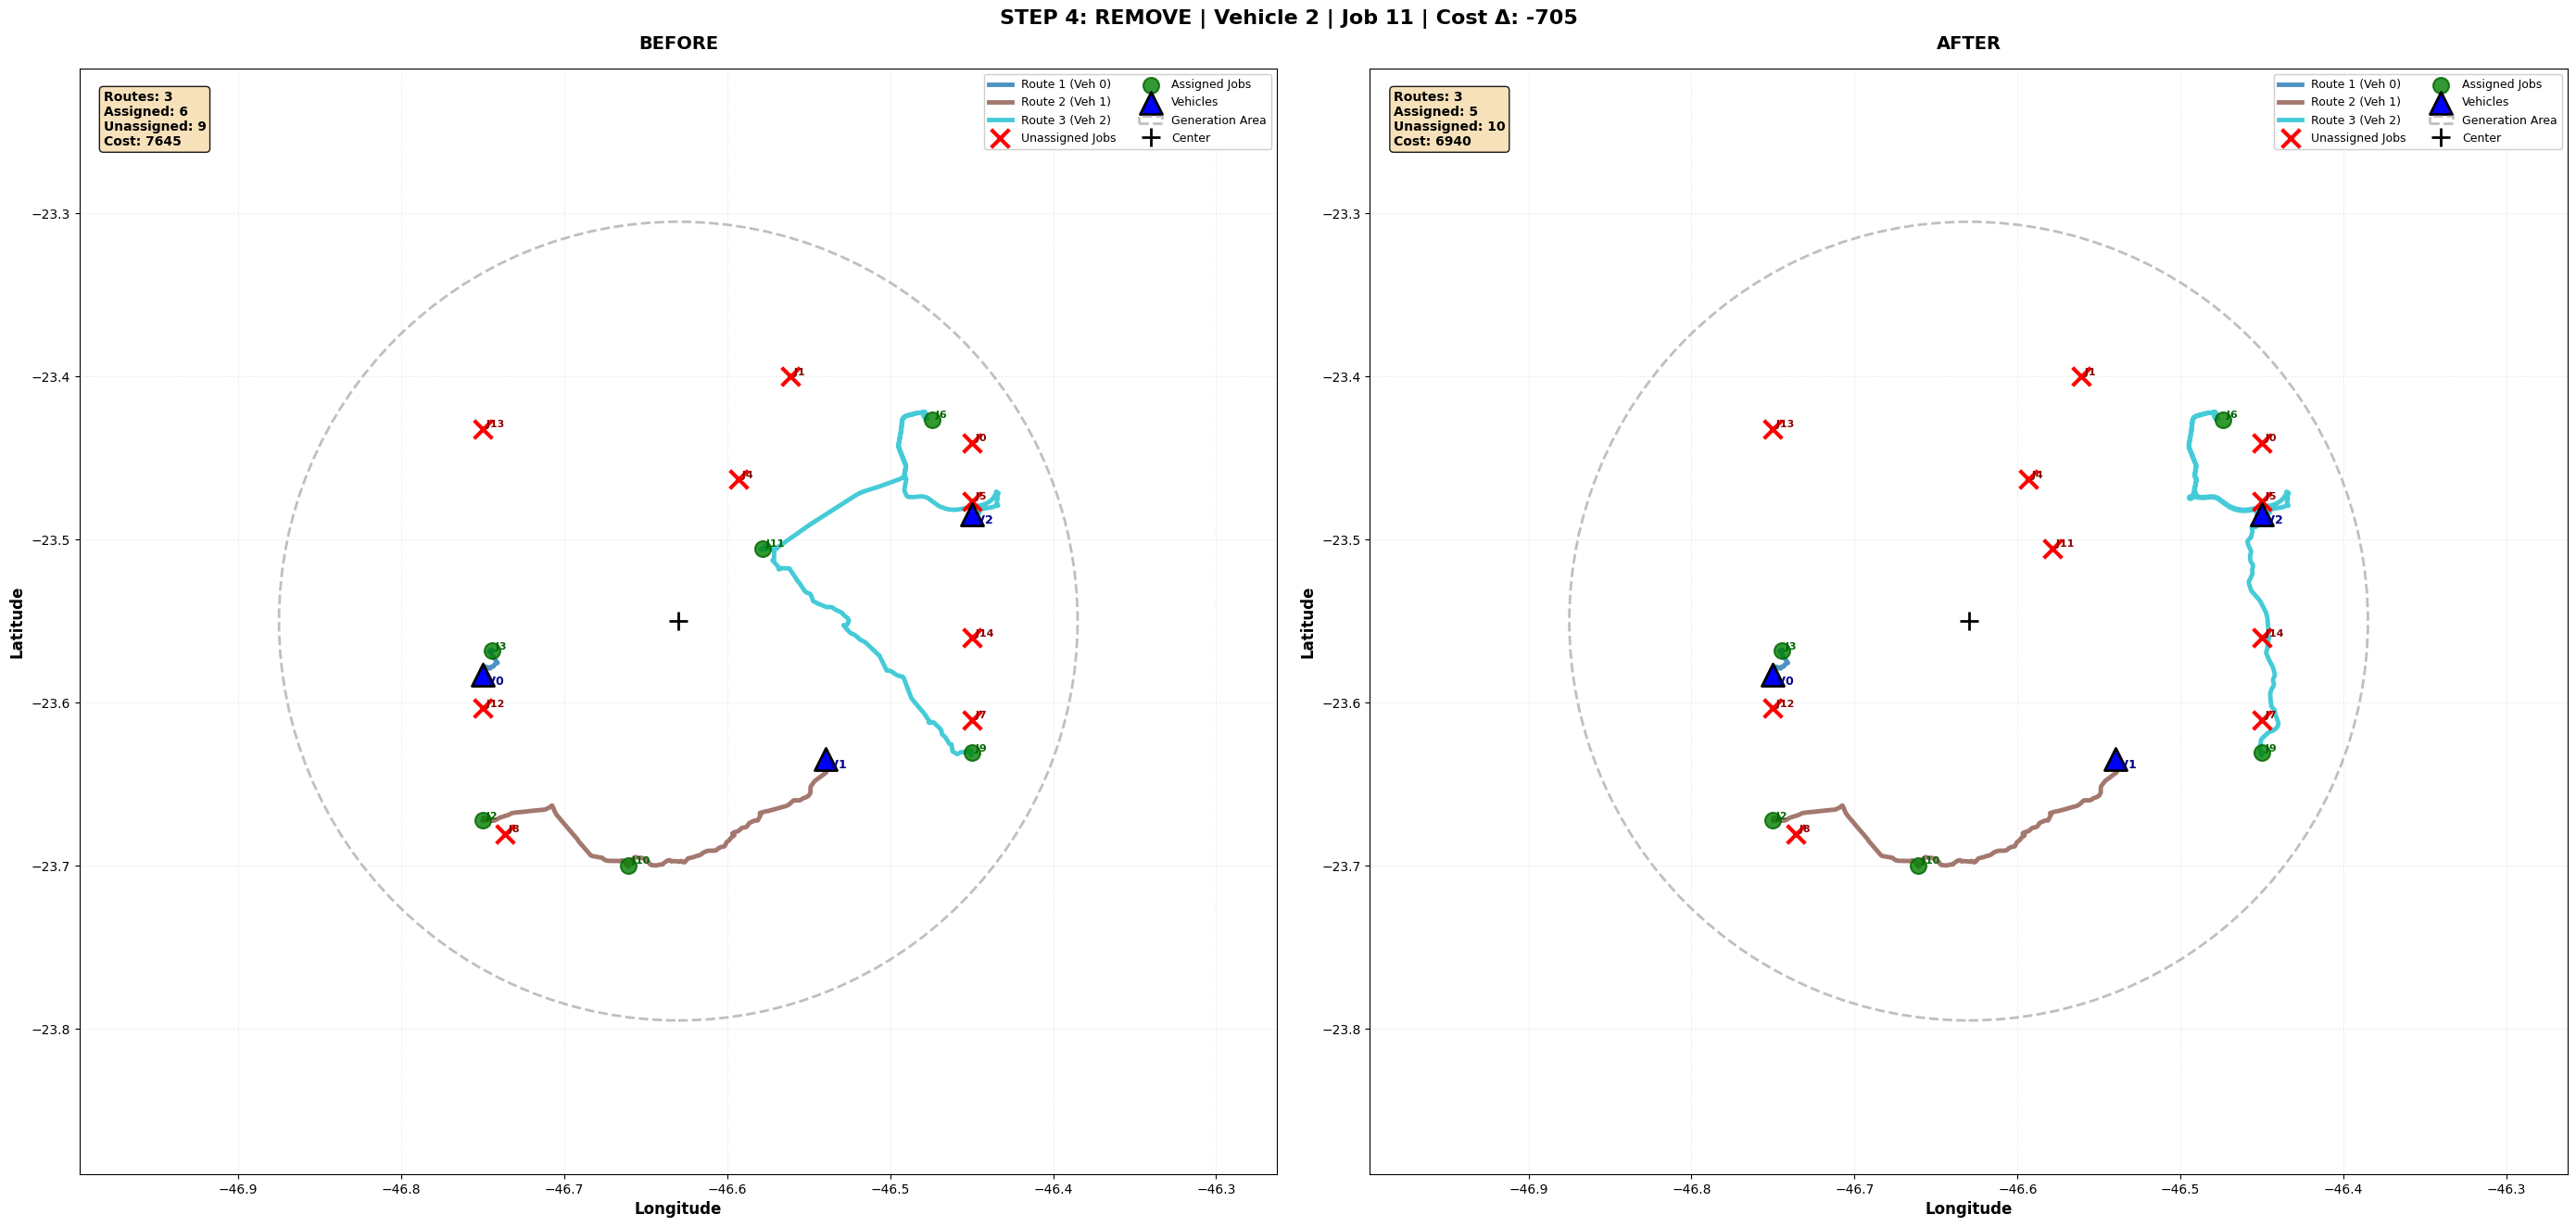

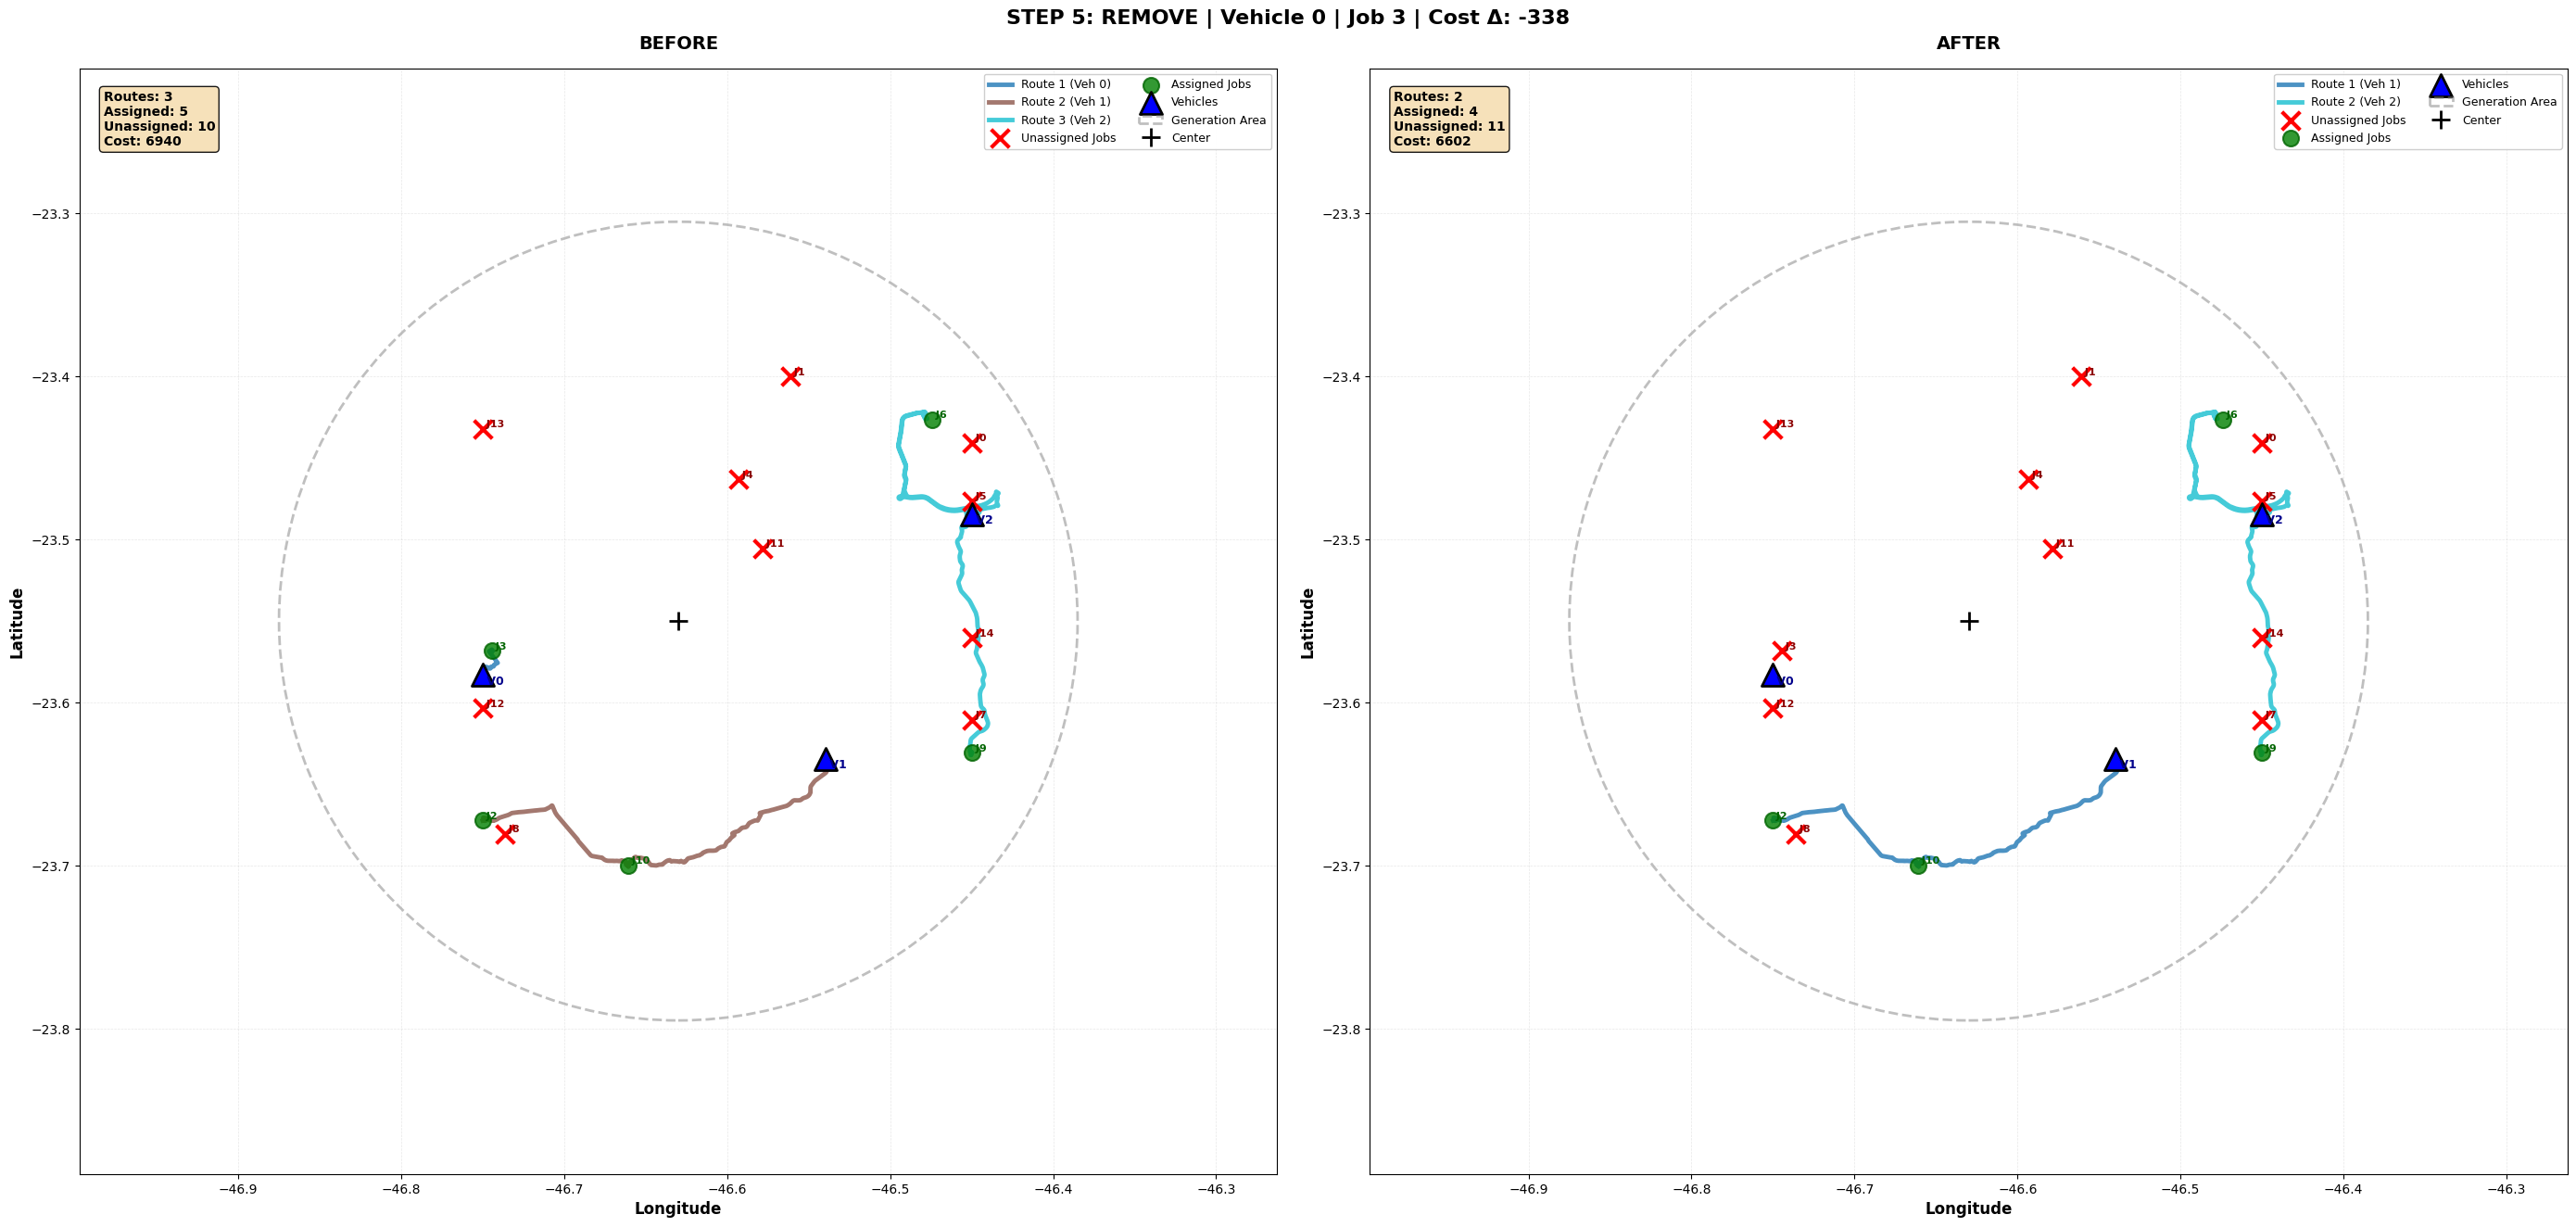

In [10]:
for idx in range(1, len(result.steps)):
    step = result.steps[idx]
    prev_step = result.steps[idx-1]
    
    action_name = step.action_info['operator_name'] if step.action_info else 'N/A'
    vehicle_id = step.action_info['vehicle_id'] if step.action_info else 'N/A'
    job_id = step.action_info['job_id'] if step.action_info else 'N/A'
    cost_delta = step.cost - prev_step.cost
    
    title = f"STEP {step.step_number}: {action_name} | Vehicle {vehicle_id} | Job {job_id} | Cost Δ: {cost_delta:+d}"
    
    plot_state_comparison(env, prev_step.state, step.state, title=title)

## Cost Evolution Visualization

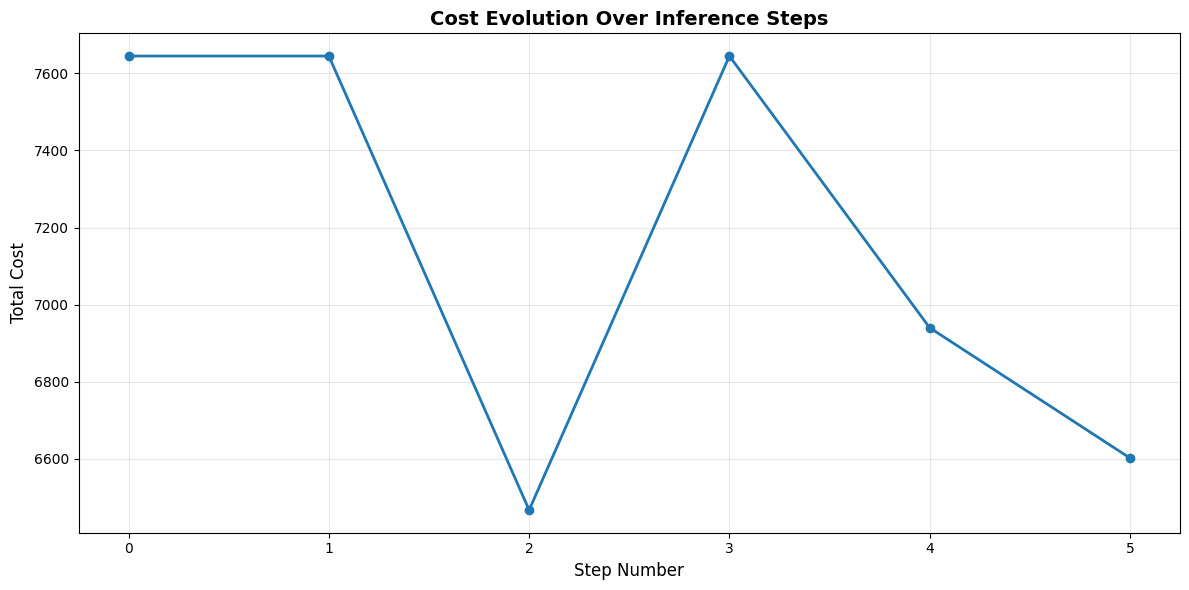

In [11]:
steps = [s.step_number for s in result.steps]
costs = [s.cost for s in result.steps]

plt.figure(figsize=(12, 6))
plt.plot(steps, costs, marker='o', linewidth=2, markersize=6)
plt.xlabel('Step Number', fontsize=12)
plt.ylabel('Total Cost', fontsize=12)
plt.title('Cost Evolution Over Inference Steps', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Multi-Metric Visualization

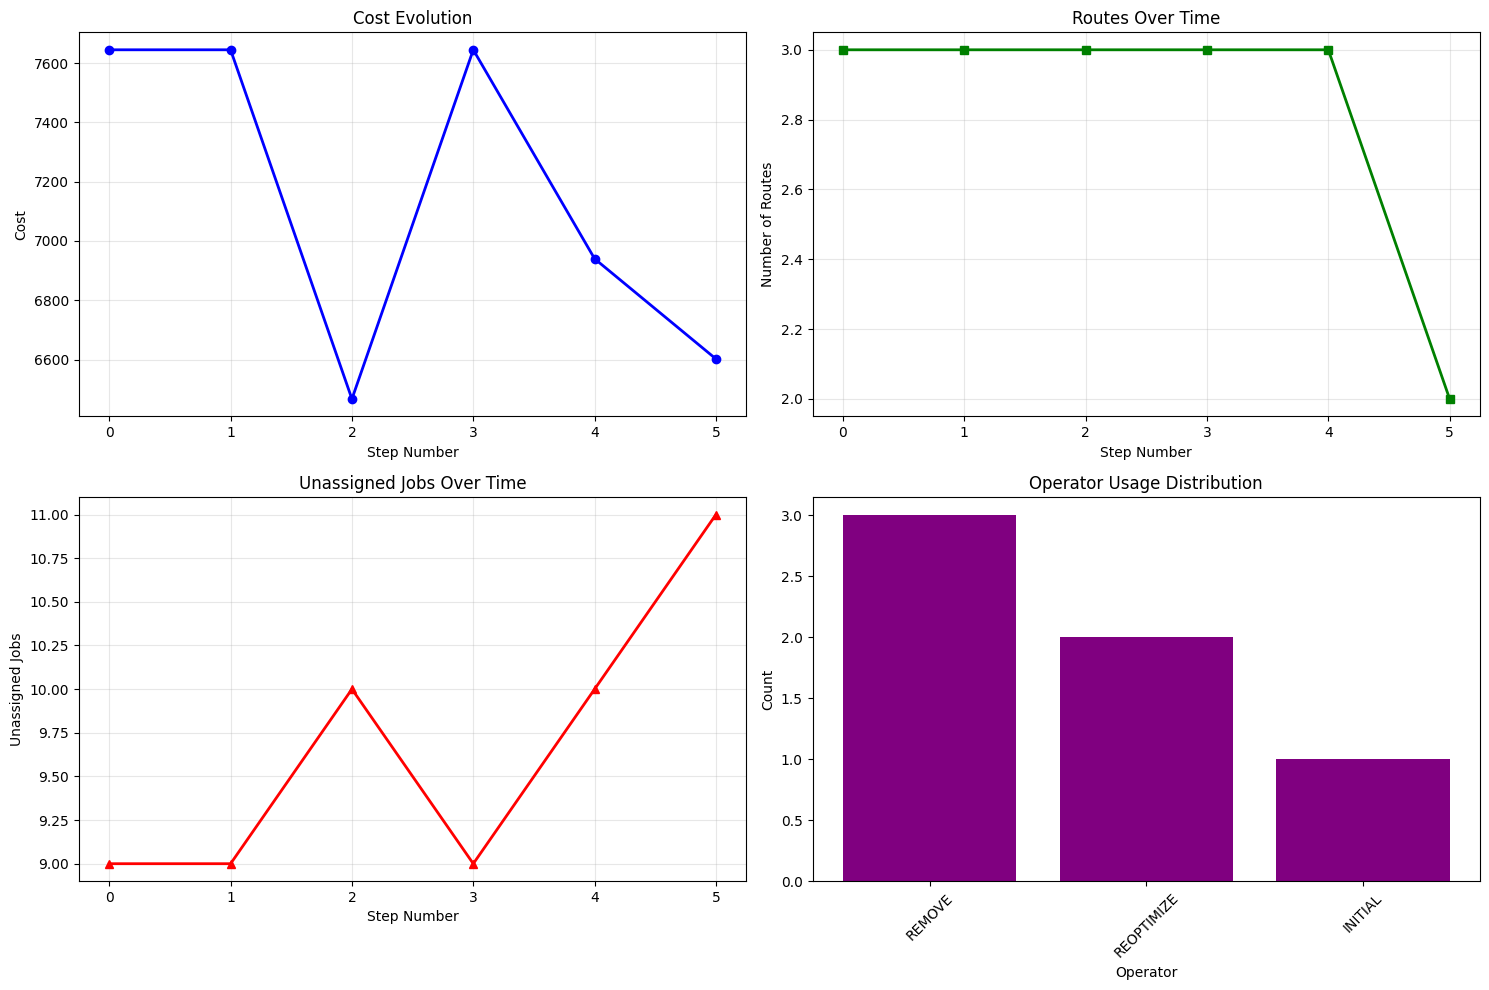

In [12]:
steps = [s.step_number for s in result.steps]
costs = [s.cost for s in result.steps]
routes = [s.num_routes for s in result.steps]
unassigned = [s.num_unassigned for s in result.steps]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(steps, costs, marker='o', color='blue', linewidth=2)
axes[0, 0].set_xlabel('Step Number')
axes[0, 0].set_ylabel('Cost')
axes[0, 0].set_title('Cost Evolution')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(steps, routes, marker='s', color='green', linewidth=2)
axes[0, 1].set_xlabel('Step Number')
axes[0, 1].set_ylabel('Number of Routes')
axes[0, 1].set_title('Routes Over Time')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(steps, unassigned, marker='^', color='red', linewidth=2)
axes[1, 0].set_xlabel('Step Number')
axes[1, 0].set_ylabel('Unassigned Jobs')
axes[1, 0].set_title('Unassigned Jobs Over Time')
axes[1, 0].grid(True, alpha=0.3)

operators = [s.action_info['operator_name'] if s.action_info else 'INITIAL' for s in result.steps]
operator_counts = pd.Series(operators).value_counts()
axes[1, 1].bar(operator_counts.index, operator_counts.values, color='purple')
axes[1, 1].set_xlabel('Operator')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Operator Usage Distribution')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Final State Parameters

In [13]:
final = result.final_state
print("="*60)
print("FINAL STATE")
print("="*60)
print(f"Total Cost: {final.cost}")
print(f"Number of Routes: {final.num_routes}")
print(f"Number of Unassigned: {final.num_unassigned}")
print(f"\nRoute Details:")
for i, route in enumerate(final.routes):
    print(f"  Route {i}: {len(route)} jobs - {route}")
print(f"\nUnassigned Jobs: {final.unassigned}")

FINAL STATE
Total Cost: 6602
Number of Routes: 2
Number of Unassigned: 11

Route Details:
  Route 0: 16 jobs - {'vehicle': 1, 'cost': 2800, 'description': 'Vehicle 1', 'delivery': [2], 'amount': [2], 'pickup': [0], 'setup': 0, 'service': 600, 'duration': 2800, 'waiting_time': 0, 'priority': 9, 'distance': 29376, 'steps': [{'type': 'start', 'location': [-46.539894, -23.634342], 'setup': 0, 'service': 0, 'waiting_time': 0, 'load': [2], 'arrival': 28800, 'duration': 0, 'violations': [], 'distance': 0}, {'type': 'job', 'description': 'Job 10', 'location': [-46.660952, -23.7], 'id': 10, 'setup': 0, 'service': 300, 'waiting_time': 0, 'job': 10, 'load': [1], 'arrival': 30422, 'duration': 1622, 'violations': [], 'distance': 17356}, {'type': 'job', 'description': 'Job 2', 'location': [-46.75, -23.672398], 'id': 2, 'setup': 0, 'service': 300, 'waiting_time': 0, 'job': 2, 'load': [0], 'arrival': 31900, 'duration': 2800, 'violations': [], 'distance': 29376}, {'type': 'end', 'location': [-46.75, -2

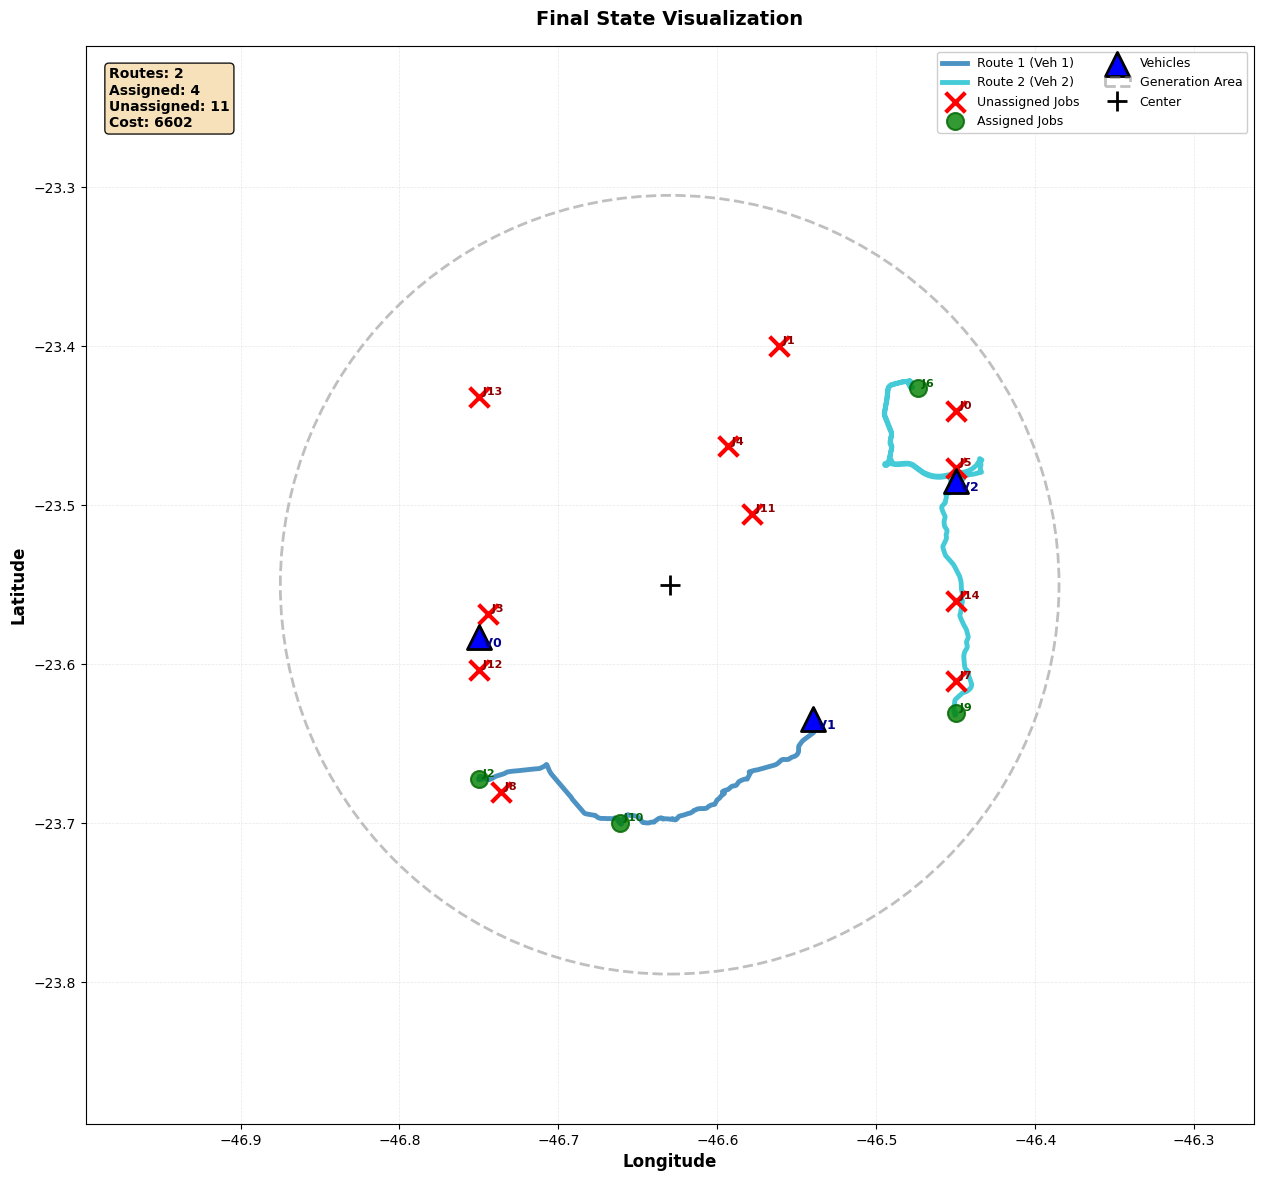

In [14]:
plot_state(env, final, title="Final State Visualization")

## Overall Comparison: Initial vs Final State

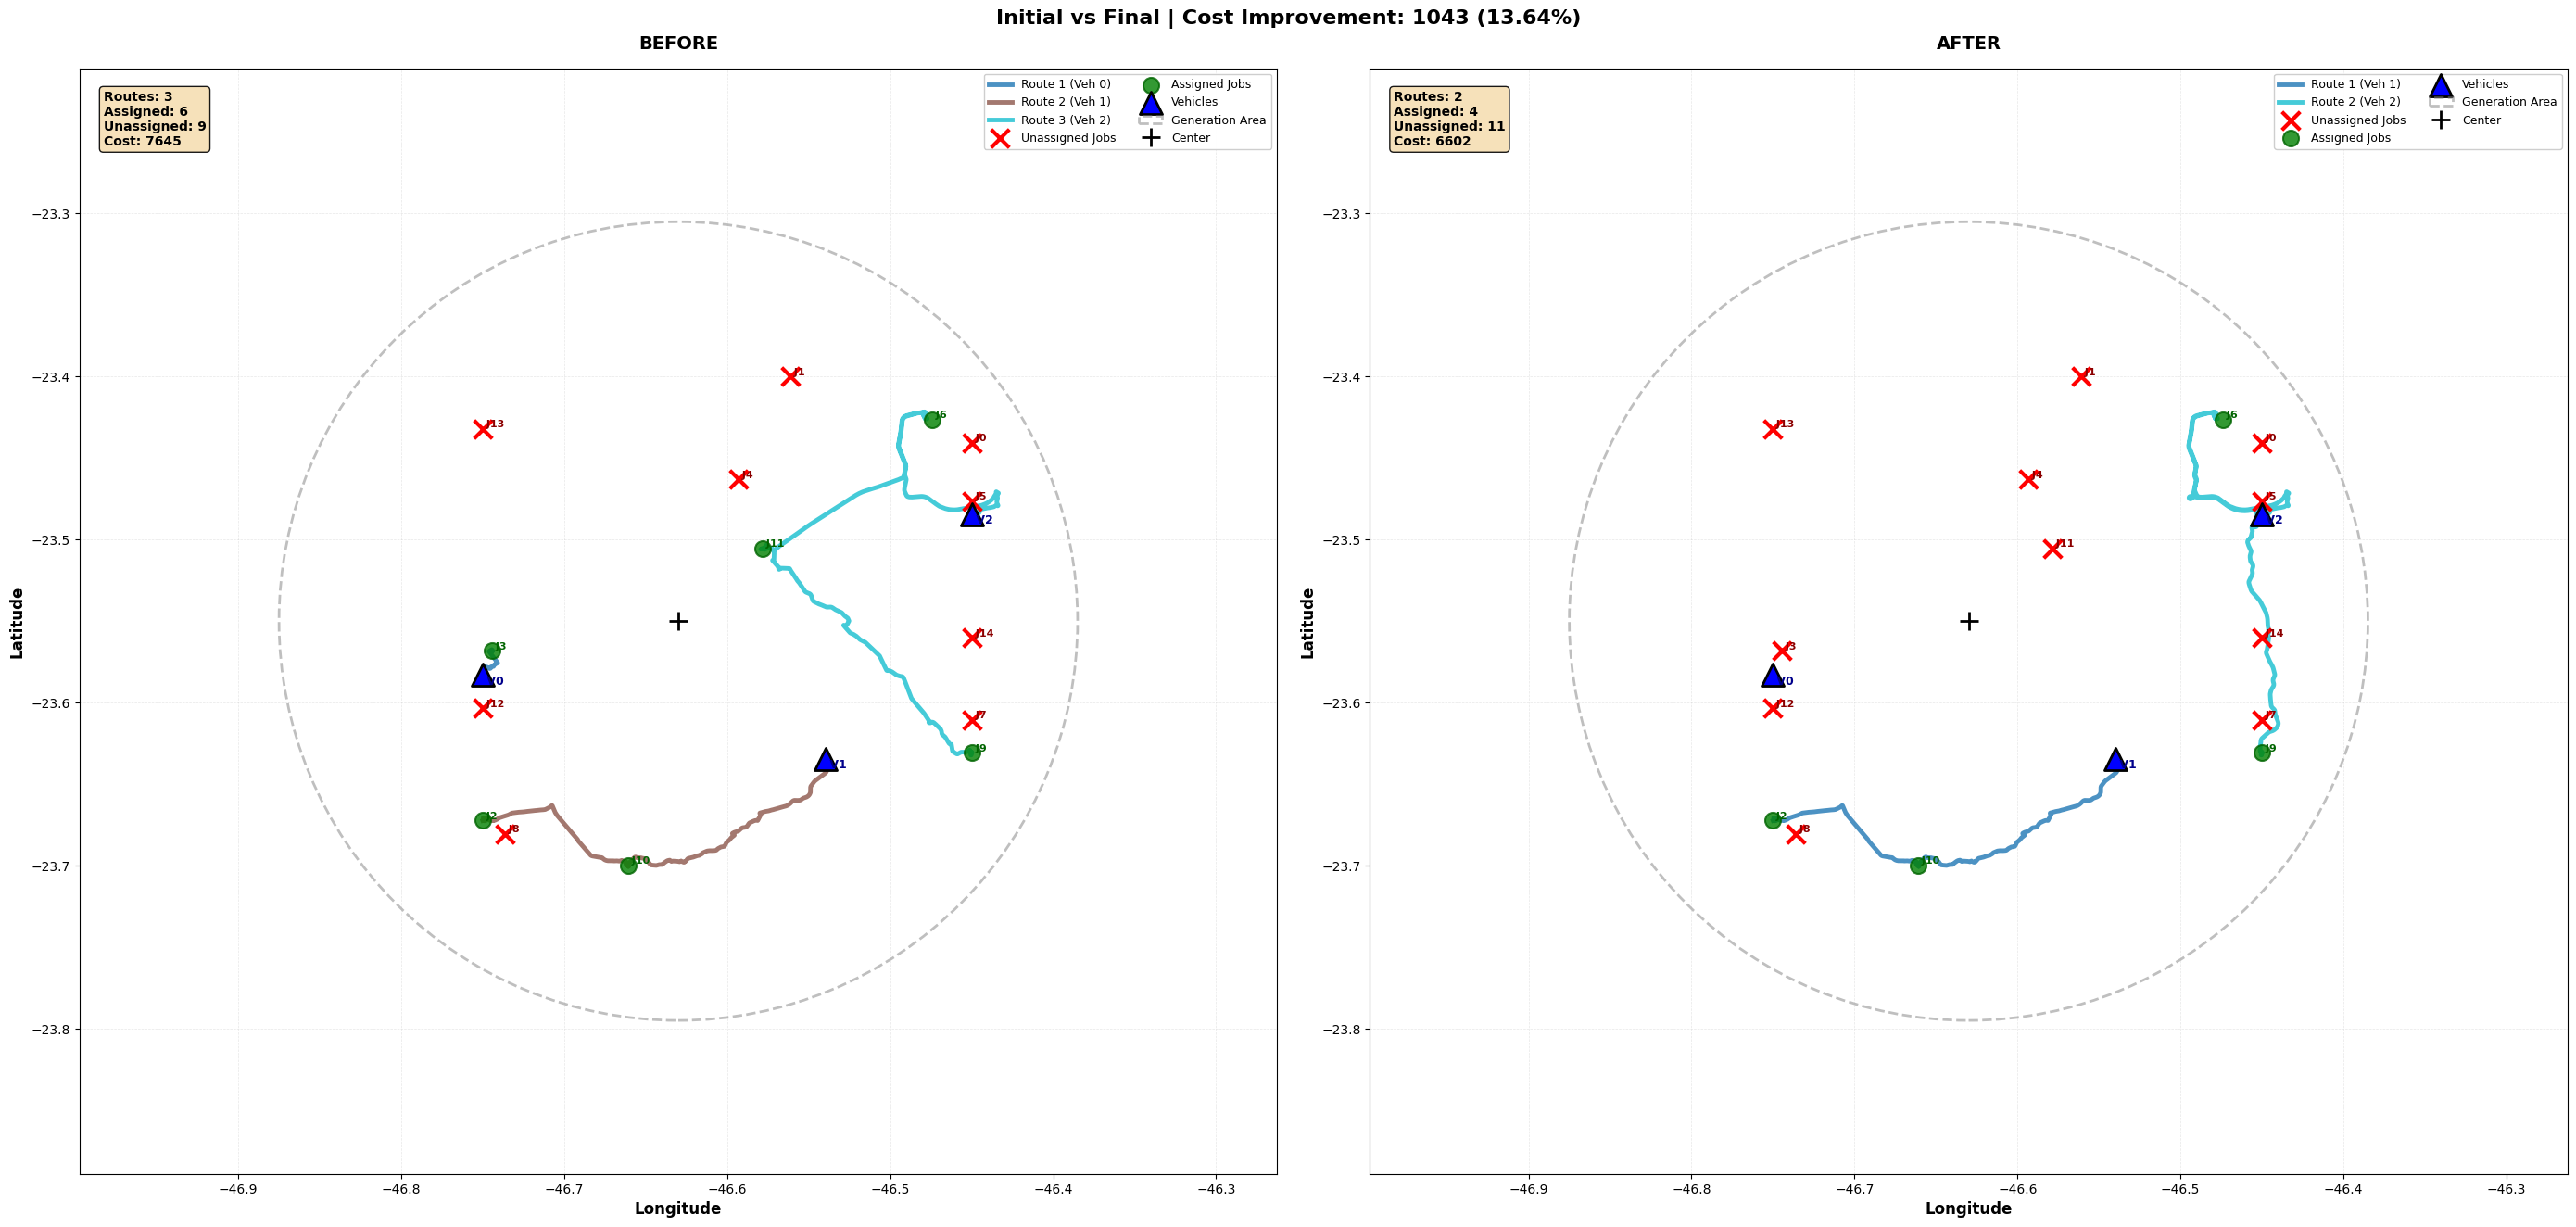

In [15]:
cost_improvement = result.get_cost_improvement()
cost_improvement_pct = result.get_cost_improvement_percentage()

title = f"Initial vs Final | Cost Improvement: {cost_improvement} ({cost_improvement_pct:.2f}%)"
plot_state_comparison(env, result.initial_state, result.final_state, title=title)

## Combined Results Summary

In [16]:
summary = result.summary()

print("="*60)
print("OVERALL SUMMARY")
print("="*60)
for key, value in summary.items():
    print(f"{key:.<30} {value}")
print("="*60)

summary_df = pd.DataFrame([summary])
display(summary_df)

OVERALL SUMMARY
total_steps................... 5
stopped_reason................ max_steps_reached
initial_cost.................. 7645
final_cost.................... 6602
cost_improvement.............. 1043
cost_improvement_pct.......... 13.642903858731199
initial_routes................ 3
final_routes.................. 2
initial_unassigned............ 9
final_unassigned.............. 11


,total_steps,stopped_reason,initial_cost,final_cost,cost_improvement,cost_improvement_pct,initial_routes,final_routes,initial_unassigned,final_unassigned
0,5,max_steps_reached,7645,6602,1043,13.642904,3,2,9,11


## Export Results to DataFrame

In [17]:
trajectory = result.get_trajectory()
trajectory_df = pd.DataFrame(trajectory)

print("Trajectory DataFrame:")
display(trajectory_df)

trajectory_df.to_csv('inference_trajectory.csv', index=False)
print("\nTrajectory exported to 'inference_trajectory.csv'")

detailed_steps = []
for idx in range(len(result.steps)):
    step = result.steps[idx]
    step_data = {
        'step_number': step.step_number,
        'cost': step.cost,
        'num_routes': step.num_routes,
        'num_unassigned': step.num_unassigned,
    }
    
    if step.action_info:
        step_data.update({
            'operator': step.action_info['operator_name'],
            'vehicle_id': step.action_info['vehicle_id'],
            'job_id': step.action_info['job_id'],
        })
    
    if step.reward_info:
        for key, value in step.reward_info.items():
            step_data[f'reward_{key}'] = value
    
    detailed_steps.append(step_data)

detailed_df = pd.DataFrame(detailed_steps)
print("\nDetailed Steps DataFrame:")
display(detailed_df)

detailed_df.to_csv('inference_detailed_steps.csv', index=False)
print("\nDetailed steps exported to 'inference_detailed_steps.csv'")

Trajectory DataFrame:


,step_number,cost,num_routes,num_unassigned,operator,vehicle_index,job_index
0,0,7645,3,9,NaN,NaN,NaN
1,1,7645,3,9,3.0,0.0,3.0
2,2,6467,3,10,1.0,1.0,2.0
3,3,7645,3,9,3.0,1.0,10.0
4,4,6940,3,10,1.0,2.0,11.0
5,5,6602,2,11,1.0,0.0,3.0



Trajectory exported to 'inference_trajectory.csv'

Detailed Steps DataFrame:


,step_number,cost,num_routes,num_unassigned,operator,vehicle_id,job_id,reward_distance_reward,reward_unassigned_reward,reward_idle_reward,reward_priority_reward,reward_action_reward,reward_old_distance_cost,reward_old_unassigned_cost,reward_old_idle_cost,reward_old_priority_cost,reward_new_distance_cost,reward_new_unassigned_cost,reward_new_idle_cost,reward_new_priority_cost
0,0,7645,3,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,7645,3,9,REOPTIMIZE,0.0,3.0,-0.0000,-0.0,-0.0,-0.0,-1.5,11.4675,9.0,0.0,9.0,11.4675,9.0,0.0,9.0
2,2,6467,3,10,REMOVE,1.0,2.0,1.7670,-1.0,-0.0,-2.0,1.5,11.4675,9.0,0.0,9.0,9.7005,10.0,0.0,11.0
3,3,7645,3,9,REOPTIMIZE,1.0,10.0,-1.7670,1.0,-0.0,2.0,-1.5,9.7005,10.0,0.0,11.0,11.4675,9.0,0.0,9.0
4,4,6940,3,10,REMOVE,2.0,11.0,1.0575,-1.0,-0.0,-2.0,1.5,11.4675,9.0,0.0,9.0,10.4100,10.0,0.0,11.0
5,5,6602,2,11,REMOVE,0.0,3.0,0.5070,-1.0,-0.5,-1.5,1.5,10.4100,10.0,0.0,11.0,9.9030,11.0,0.5,12.5



Detailed steps exported to 'inference_detailed_steps.csv'


## Before and After Comparison Table

In [18]:
comparison_data = []

for idx in range(1, len(result.steps)):
    step = result.steps[idx]
    prev_step = result.steps[idx-1]
    
    comparison_data.append({
        'Step': step.step_number,
        'Action': step.action_info['operator_name'] if step.action_info else 'N/A',
        'Cost_Before': prev_step.cost,
        'Cost_After': step.cost,
        'Cost_Delta': step.cost - prev_step.cost,
        'Routes_Before': prev_step.num_routes,
        'Routes_After': step.num_routes,
        'Unassigned_Before': prev_step.num_unassigned,
        'Unassigned_After': step.num_unassigned,
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

comparison_df.to_csv('inference_before_after_comparison.csv', index=False)
print("\nComparison exported to 'inference_before_after_comparison.csv'")

,Step,Action,Cost_Before,Cost_After,Cost_Delta,Routes_Before,Routes_After,Unassigned_Before,Unassigned_After
0,1,REOPTIMIZE,7645,7645,0,3,3,9,9
1,2,REMOVE,7645,6467,-1178,3,3,9,10
2,3,REOPTIMIZE,6467,7645,1178,3,3,10,9
3,4,REMOVE,7645,6940,-705,3,3,9,10
4,5,REMOVE,6940,6602,-338,3,2,10,11



Comparison exported to 'inference_before_after_comparison.csv'


## Aggregate Performance Metrics

In [19]:
cost_improvements = [result.steps[i].cost - result.steps[i-1].cost for i in range(1, len(result.steps))]
total_positive_improvements = sum([x for x in cost_improvements if x < 0])
total_negative_improvements = sum([x for x in cost_improvements if x > 0])
num_improving_steps = len([x for x in cost_improvements if x < 0])
num_degrading_steps = len([x for x in cost_improvements if x > 0])

print("="*60)
print("AGGREGATE PERFORMANCE METRICS")
print("="*60)
print(f"Total Steps: {result.total_steps}")
print(f"Steps with Cost Improvement: {num_improving_steps}")
print(f"Steps with Cost Degradation: {num_degrading_steps}")
print(f"Total Cost Reduction: {total_positive_improvements}")
print(f"Total Cost Increase: {total_negative_improvements}")
print(f"Net Cost Change: {result.get_final_cost() - result.get_initial_cost()}")
print(f"Cost Improvement Percentage: {result.get_cost_improvement_percentage():.2f}%")
print("="*60)

metrics_dict = {
    'total_steps': result.total_steps,
    'improving_steps': num_improving_steps,
    'degrading_steps': num_degrading_steps,
    'total_cost_reduction': total_positive_improvements,
    'total_cost_increase': total_negative_improvements,
    'net_cost_change': result.get_final_cost() - result.get_initial_cost(),
    'cost_improvement_pct': result.get_cost_improvement_percentage()
}

metrics_df = pd.DataFrame([metrics_dict])
display(metrics_df)

AGGREGATE PERFORMANCE METRICS
Total Steps: 5
Steps with Cost Improvement: 3
Steps with Cost Degradation: 1
Total Cost Reduction: -2221
Total Cost Increase: 1178
Net Cost Change: -1043
Cost Improvement Percentage: 13.64%


,total_steps,improving_steps,degrading_steps,total_cost_reduction,total_cost_increase,net_cost_change,cost_improvement_pct
0,5,3,1,-2221,1178,-1043,13.642904


## Cost Change Distribution

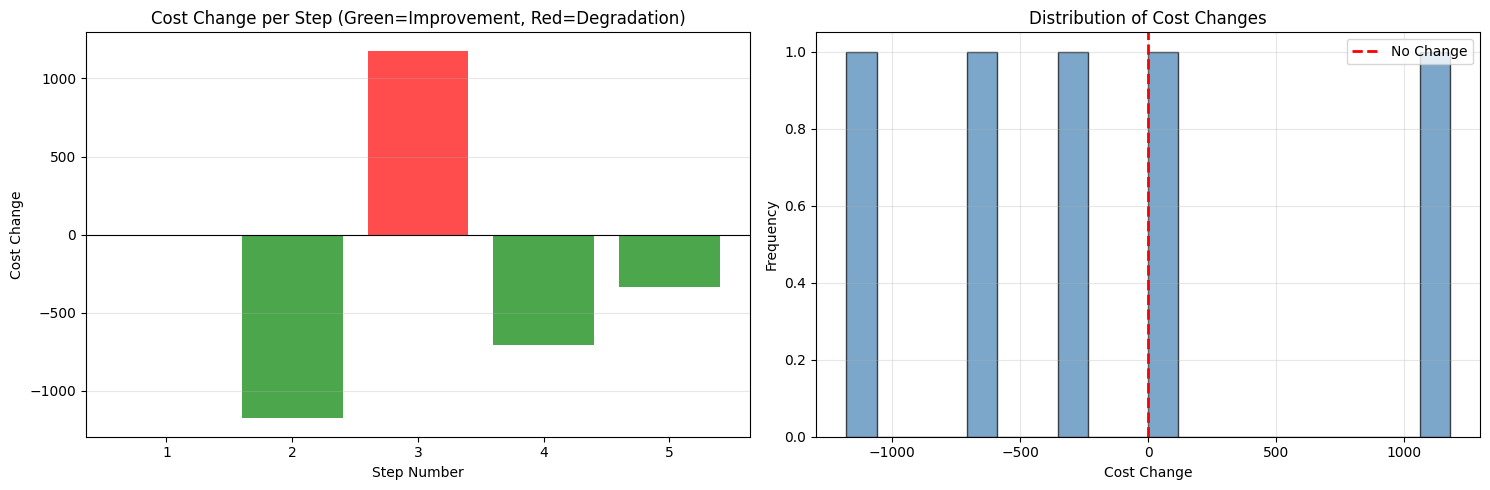

In [20]:
cost_deltas = [result.steps[i].cost - result.steps[i-1].cost for i in range(1, len(result.steps))]
step_numbers = [result.steps[i].step_number for i in range(1, len(result.steps))]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ['green' if x < 0 else 'red' if x > 0 else 'gray' for x in cost_deltas]
axes[0].bar(step_numbers, cost_deltas, color=colors, alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[0].set_xlabel('Step Number')
axes[0].set_ylabel('Cost Change')
axes[0].set_title('Cost Change per Step (Green=Improvement, Red=Degradation)')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].hist(cost_deltas, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Change')
axes[1].set_xlabel('Cost Change')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Cost Changes')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusion

All inference results have been visualized and analyzed. The notebook provides:
- Initial and final state parameters
- Step-by-step action details with before/after comparisons
- Cost evolution visualization
- Multi-metric performance tracking
- Aggregate performance metrics
- Exported data to CSV files for further analysis